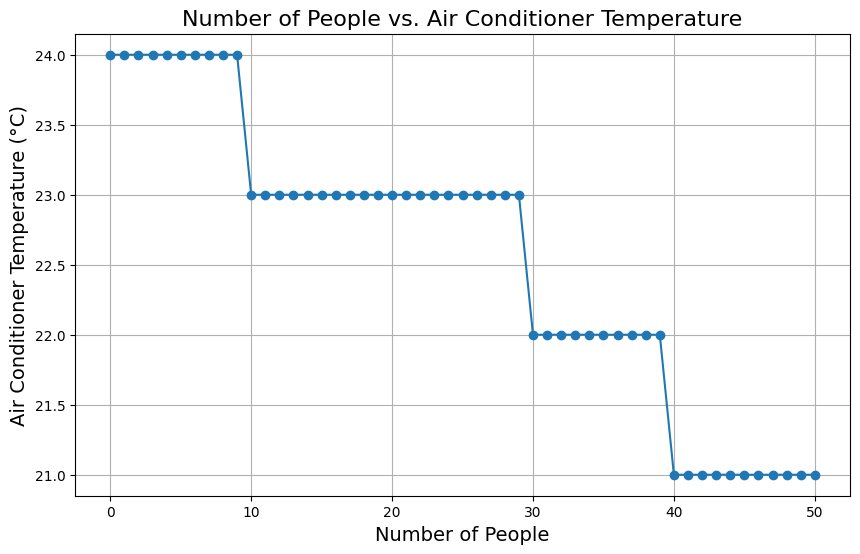

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# 변수 설정
initial_temperature = 24  # 초기 에어컨 온도 (C)
max_people = 50  # 최대 인원수
external_temperature = 30  # 외부 온도 (C)

# 사람 수에 따른 에어컨 온도 조절 함수 (기본적인 예)
def adjust_aircon_temperature(people_count):
    # 인원이 많아질수록 에어컨 온도를 낮추는 단순 로직
    if people_count < 10:
        return initial_temperature
    elif people_count < 30:
        return initial_temperature - 1  # 인원이 10~30명이면 온도를 1도 낮춤
    elif people_count < 40:
        return initial_temperature - 2  # 인원이 30~40명이면 온도를 2도 낮춤
    else:
        return initial_temperature - 3  # 인원이 40명 이상이면 온도를 3도 낮춤

# 사람 수와 조정된 온도를 저장할 리스트
people_counts = np.arange(0, max_people + 1)
adjusted_temperatures = [adjust_aircon_temperature(p) for p in people_counts]

# 그래프 그리기
plt.figure(figsize=(10, 6))
plt.plot(people_counts, adjusted_temperatures, marker='o')
plt.title('Number of People vs. Air Conditioner Temperature', fontsize=16)
plt.xlabel('Number of People', fontsize=14)
plt.ylabel('Air Conditioner Temperature (°C)', fontsize=14)
plt.grid(True)

# 그래프 출력
plt.show()


In [ ]:
import cv2

# YOLO 모델 불러오기
net = cv2.dnn.readNet("yolov3.weights", "yolov3.cfg")
layer_names = net.getLayerNames()
output_layers = [layer_names[i[0] - 1] for i in net.getUnconnectedOutLayers()]

# 클래스명 불러오기
with open("coco.names", "r") as f:
    classes = [line.strip() for line in f.readlines()]

# 카메라 또는 비디오 파일 불러오기
cap = cv2.VideoCapture(0)  # 0번 카메라는 기본 웹캠

while True:
    _, frame = cap.read()
    height, width, channels = frame.shape

    # 이미지 전처리
    blob = cv2.dnn.blobFromImage(frame, 0.00392, (416, 416), (0, 0, 0), True, crop=False)
    net.setInput(blob)
    outs = net.forward(output_layers)

    # 객체 감지 정보 저장
    class_ids = []
    confidences = []
    boxes = []

    for out in outs:
        for detection in out:
            scores = detection[5:]
            class_id = np.argmax(scores)
            confidence = scores[class_id]
            if confidence > 0.5 and classes[class_id] == "person":  # 'person' 클래스만 필터링
                # 객체 정보 추출
                center_x = int(detection[0] * width)
                center_y = int(detection[1] * height)
                w = int(detection[2] * width)
                h = int(detection[3] * height)

                # 좌표 추출
                x = int(center_x - w / 2)
                y = int(center_y - h / 2)

                boxes.append([x, y, w, h])
                confidences.append(float(confidence))
                class_ids.append(class_id)

    # Non-maxima suppression 적용
    indexes = cv2.dnn.NMSBoxes(boxes, confidences, 0.5, 0.4)

    # 감지된 객체 표시
    for i in range(len(boxes)):
        if i in indexes:
            x, y, w, h = boxes[i]
            label = str(classes[class_ids[i]])
            cv2.rectangle(frame, (x, y), (x + w, y + h), (0, 255, 0), 2)
            cv2.putText(frame, label, (x, y - 10), cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0, 255, 0), 2)

    # 결과 화면 출력
    cv2.imshow("Image", frame)

    if cv2.waitKey(1) & 0xFF == ord('q'):
        break

cap.release()
cv2.destroyAllWindows()


error: OpenCV(4.10.0) /io/opencv/modules/dnn/src/darknet/darknet_importer.cpp:210: error: (-212:Parsing error) Failed to open NetParameter file: yolov3.cfg in function 'readNetFromDarknet'


In [ ]:
!pip install ultralytics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 886.3/886.3 kB 20.1 MB/s eta 0:00:00


In [ ]:
from google.colab import files
from ultralytics import YOLO
import matplotlib.pyplot as plt
import cv2
import numpy as np

# YOLO 모델 로드
model = YOLO("yolov8n.pt")

# 이미지 업로드
uploaded = files.upload()
image_path = list(uploaded.keys())[0]  # 업로드된 이미지 파일 이름

# 이미지에서 사람 객체 감지
results = model(image_path)

# 감지된 결과 이미지 표시
for result in results:
    annotated_img = result.plot()  # 결과 이미지에 박스를 그립니다.
    plt.imshow(cv2.cvtColor(annotated_img, cv2.COLOR_BGR2RGB))
    plt.axis("off")
    plt.show()

ModuleNotFoundError: No module named 'ultralytics'

In [ ]:
from google.colab import files
from ultralytics import YOLO
import matplotlib.pyplot as plt
import cv2

# YOLO 모델 로드
model = YOLO("yolov8n.pt")

# 이미지 업로드
uploaded = files.upload()
image_path = list(uploaded.keys())[0]  # 업로드된 이미지 파일 이름

# 이미지에서 사람 객체 감지
results = model(image_path)

# 감지된 결과 중 "person"만 표시
for result in results:
    # 감지된 박스 및 클래스 정보 가져오기
    boxes = result.boxes
    person_boxes = boxes[boxes.cls == 0]  # '0'은 'person' 클래스의 인덱스입니다

    # 결과 이미지에 사람 객체만 시각화
    annotated_img = result.plot()

    for box in person_boxes:  # 각 person 박스에 대해
        # 바운딩 박스 좌표
        x1, y1, x2, y2 = box.xyxy[0].int().tolist()
        cv2.rectangle(annotated_img, (x1, y1), (x2, y2), color=(0, 255, 0), thickness=2)  # 초록색 박스 추가

    plt.imshow(cv2.cvtColor(annotated_img, cv2.COLOR_BGR2RGB))
    plt.axis("off")
    plt.show()

ModuleNotFoundError: No module named 'ultralytics'

Saving KakaoTalk_20241114_122536186_01.jpg to KakaoTalk_20241114_122536186_01.jpg

image 1/1 /content/KakaoTalk_20241114_122536186_01.jpg: 480x640 8 persons, 5 chairs, 7 dining tables, 1 cell phone, 1 refrigerator, 185.8ms
Speed: 3.4ms preprocess, 185.8ms inference, 1.4ms postprocess per image at shape (1, 3, 480, 640)


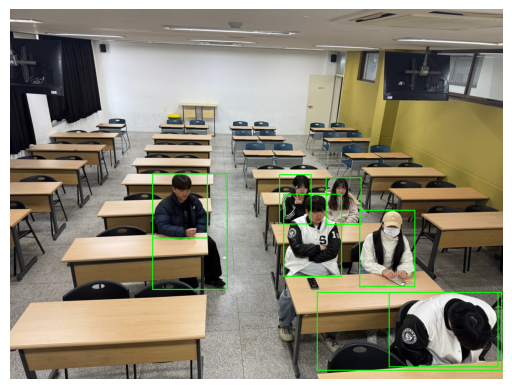

True

In [ ]:
from google.colab import files
from ultralytics import YOLO
import matplotlib.pyplot as plt
import cv2

# YOLO 모델 로드
model = YOLO("yolov8n.pt")

# 이미지 업로드
uploaded = files.upload()
image_path = list(uploaded.keys())[0]  # 업로드된 이미지 파일 이름

# 이미지에서 사람 객체 감지
results = model(image_path)

# 원본 이미지 로드
original_img = cv2.imread(image_path)

# 감지된 결과 중 "person"만 표시
for result in results:
    # 감지된 박스 및 클래스 정보 가져오기
    boxes = result.boxes
    person_boxes = boxes[boxes.cls == 0]  # '0'은 'person' 클래스의 인덱스입니다

    # 네모 테두리 추가
    for box in person_boxes:  # 각 person 박스에 대해
        # 바운딩 박스 좌표
        x1, y1, x2, y2 = box.xyxy[0].int().tolist()
        cv2.rectangle(original_img, (x1, y1), (x2, y2), color=(0, 255, 0), thickness=2)  # 초록색 박스 추가

# 결과 이미지 표시
plt.imshow(cv2.cvtColor(original_img, cv2.COLOR_BGR2RGB))
plt.axis("off")
plt.show()

# 결과 이미지 저장 (원하는 파일명으로 변경 가능)
cv2.imwrite("person_with_boxes.jpg", original_img)

Saving KakaoTalk_20241114_122536186_01.jpg to KakaoTalk_20241114_122536186_01 (8).jpg

image 1/1 /content/KakaoTalk_20241114_122536186_01 (8).jpg: 480x640 8 persons, 5 chairs, 7 dining tables, 1 cell phone, 1 refrigerator, 180.6ms
Speed: 3.3ms preprocess, 180.6ms inference, 1.4ms postprocess per image at shape (1, 3, 480, 640)


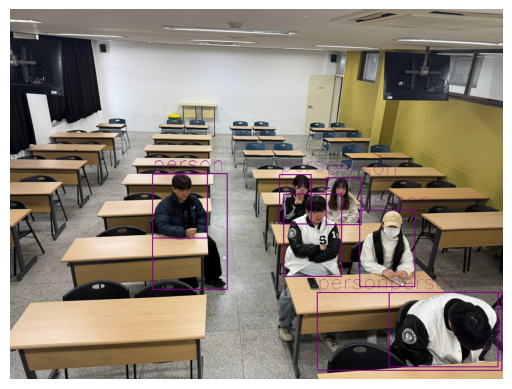

True

In [ ]:
from google.colab import files
from ultralytics import YOLO
import matplotlib.pyplot as plt
import cv2

# YOLO 모델 로드
model = YOLO("yolov8n.pt")

# 이미지 업로드
uploaded = files.upload()
image_path = list(uploaded.keys())[0]  # 업로드된 이미지 파일 이름

# 이미지에서 객체 감지
results = model(image_path)

# 원본 이미지 로드
original_img = cv2.imread(image_path)

# YOLO 모델의 클래스 이름 가져오기
class_names = model.names  # 클래스 이름 리스트

# 감지된 결과 중 "person"만 표시
for result in results:
    # 감지된 박스 정보 가져오기
    for box in result.boxes:
        # 감지된 객체의 클래스 인덱스 가져오기
        cls_id = int(box.cls[0])

        # 클래스가 'person'일 때만 바운딩 박스 그리기
        if class_names[cls_id] == "person":
            # 바운딩 박스 좌표 가져오기
            x1, y1, x2, y2 = box.xyxy[0].int().tolist()

            # 초록색 네모 테두리 추가
            cv2.rectangle(original_img, (x1, y1), (x2, y2), color=(128, 0, 128), thickness=2)

            # 'person' 텍스트 추가 (좌측 상단에 표시)
            cv2.putText(original_img, "person", (x1, y1 - 10), cv2.FONT_HERSHEY_SIMPLEX,
                        fontScale=2, color=(128, 0, 128), thickness=1)

# 결과 이미지 표시
plt.imshow(cv2.cvtColor(original_img, cv2.COLOR_BGR2RGB))
plt.axis("off")
plt.show()

# 결과 이미지 저장 (원하는 파일명으로 변경 가능)
cv2.imwrite("person_with_boxes.jpg", original_img)
